# Notebook 05 — Customer Segmentation (K-Means on Behavioural Features)

**Input:** `outputs/kkbox_features.parquet` — 970,960 rows, 31 model features, 0 nulls  
**Cluster features:** `avg_daily_secs`, `completion_rate`, `skip_rate`, `active_days`, `days_since_last_log`  
**Note:** 115,801 never-logged customers have all listening features = 0 and `days_since_last_log` = 820. They will naturally form the Dormant cluster — this is the correct behaviour, not a data leak.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

ROOT    = Path("..").resolve()
OUTPUTS = ROOT / "outputs"

df = pd.read_parquet(OUTPUTS / "kkbox_features.parquet")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Churn rate: {df['is_churn'].mean()*100:.2f}%")
print(f"Nulls: {df.isnull().sum().sum()}")

Loaded: 970,960 rows x 39 cols
Churn rate: 8.99%
Nulls: 0


## Section 1 — Feature Selection & Preprocessing

In [2]:
CLUSTER_FEATURES = [
    "avg_daily_secs",
    "completion_rate",
    "skip_rate",
    "active_days",
    "days_since_last_log",
]

X_raw = df[CLUSTER_FEATURES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Clustering features (StandardScaler applied):")
stats = pd.DataFrame(X_raw, columns=CLUSTER_FEATURES).describe().round(2)
print(stats.to_string())
print(f"\nScaled shape: {X_scaled.shape}")
print(f"Never-logged customers (active_days=0): {(df['active_days']==0).sum():,}")

Clustering features (StandardScaler applied):


       avg_daily_secs  completion_rate  skip_rate  active_days  days_since_last_log
count       970960.00        970960.00  970960.00    970960.00            970960.00
mean          5784.66             0.60       0.18       257.90               121.07
std           5429.91             0.29       0.15       237.84               270.97
min              0.00             0.00       0.00         0.00                 0.00
25%           2615.67             0.49       0.07        40.00                 0.00
50%           4737.24             0.69       0.15       194.00                 1.00
75%           7473.06             0.81       0.25       434.00                19.00
max          84138.61             1.00       1.00       821.00               820.00

Scaled shape: (970960, 5)
Never-logged customers (active_days=0): 115,801


## Section 2 — Find Optimal K (Elbow + Silhouette)

Fitting K-Means for k=2..8 ...


  k=2  inertia=2,902,434  silhouette=0.5683  (27.4s)


  k=3  inertia=1,996,742  silhouette=0.3790  (25.1s)


  k=4  inertia=1,491,220  silhouette=0.3952  (25.0s)


  k=5  inertia=1,136,421  silhouette=0.4163  (25.0s)


  k=6  inertia=957,311  silhouette=0.3946  (25.9s)


  k=7  inertia=854,087  silhouette=0.3746  (26.0s)


  k=8  inertia=767,580  silhouette=0.3735  (26.2s)


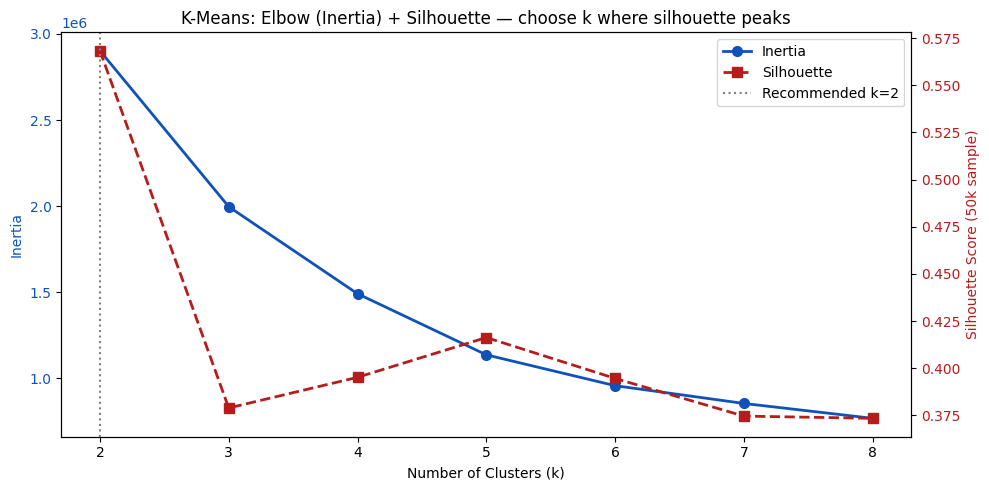


Recommended k = 2  (highest silhouette score: 0.5683)


In [3]:
import time

K_RANGE = range(2, 9)
inertias    = []
sil_scores  = []

# Silhouette on 50k sample — exact silhouette on 970k rows would be very slow
SAMPLE_N = 50_000
np.random.seed(42)
sil_idx = np.random.choice(len(X_scaled), SAMPLE_N, replace=False)
X_sil   = X_scaled[sil_idx]

print("Fitting K-Means for k=2..8 ...")
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_full = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sil, labels_full[sil_idx])
    sil_scores.append(sil)
    print(f"  k={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}  ({time.time()-t0:.1f}s)")

# Dual-axis chart
fig, ax1 = plt.subplots(figsize=(10, 5))
color_inertia = "#0F52BA"
color_sil     = "#B71C1C"

ax1.plot(list(K_RANGE), inertias, "o-", color=color_inertia, linewidth=2, markersize=7, label="Inertia")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color=color_inertia)
ax1.tick_params(axis="y", labelcolor=color_inertia)

ax2 = ax1.twinx()
ax2.plot(list(K_RANGE), sil_scores, "s--", color=color_sil, linewidth=2, markersize=7, label="Silhouette")
ax2.set_ylabel("Silhouette Score (50k sample)", color=color_sil)
ax2.tick_params(axis="y", labelcolor=color_sil)

best_k = list(K_RANGE)[sil_scores.index(max(sil_scores))]
ax2.axvline(best_k, color="gray", linestyle=":", linewidth=1.5, label=f"Recommended k={best_k}")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.set_title("K-Means: Elbow (Inertia) + Silhouette — choose k where silhouette peaks")
ax1.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig(OUTPUTS / "05_kmeans_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nRecommended k = {best_k}  (highest silhouette score: {max(sil_scores):.4f})")

## Section 3 — Fit Final Model & Name Segments

In [4]:
FINAL_K = 4  # override with best_k if silhouette clearly favours another value
print(f"Fitting final K-Means with k={FINAL_K} ...")
km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_scaled)

# Cluster profiles (unscaled means for interpretability)
profile = (
    df.groupby("cluster")[CLUSTER_FEATURES + ["is_churn"]]
    .mean()
    .round(4)
)
profile["n_customers"] = df.groupby("cluster").size()
profile["churn_rate"]  = (profile["is_churn"] * 100).round(2)
profile = profile.drop(columns=["is_churn"])
print("\nCluster profiles (unscaled means):")
print(profile.to_string())

# ── Auto-assign segment names from profile ────────────────────────────────
# Rules based on the four archetype definitions in the prompt:
#   Dormant      : highest days_since_last_log  (captures never-logged customers)
#   At-Risk      : second-highest days_since_last_log + below-median completion
#   Power Users  : highest completion_rate + highest avg_daily_secs
#   Casual       : remaining cluster

def assign_segment_names(profile):
    prof = profile.copy()
    remaining = set(prof.index)
    names = {}

    # Dormant — highest days_since_last_log
    dormant_idx = prof.loc[list(remaining), "days_since_last_log"].idxmax()
    names[dormant_idx] = "Dormant"
    remaining.discard(dormant_idx)

    # Power Users — highest completion_rate among rest
    power_idx = prof.loc[list(remaining), "completion_rate"].idxmax()
    names[power_idx] = "Power Users"
    remaining.discard(power_idx)

    # At-Risk — highest days_since_last_log among rest (second-most dormant)
    atrisk_idx = prof.loc[list(remaining), "days_since_last_log"].idxmax()
    names[atrisk_idx] = "At-Risk"
    remaining.discard(atrisk_idx)

    # Casual — whatever's left
    for idx in remaining:
        names[idx] = "Casual Listeners"

    return names

seg_map  = assign_segment_names(profile)
df["segment_label"] = df["cluster"].map(seg_map)

print("\nSegment assignments:")
for cluster_id, name in sorted(seg_map.items()):
    n = (df["cluster"] == cluster_id).sum()
    cr = df.loc[df["cluster"] == cluster_id, "is_churn"].mean() * 100
    print(f"  Cluster {cluster_id} -> {name:20s}  n={n:,}  churn={cr:.1f}%")

Fitting final K-Means with k=4 ...



Cluster profiles (unscaled means):
         avg_daily_secs  completion_rate  skip_rate  active_days  days_since_last_log  n_customers  churn_rate
cluster                                                                                                       
0             2918.6036           0.3742     0.4398     139.4935              66.8648       157106        8.92
1               18.2383           0.0041     0.0018       0.0822             815.4345       117741        5.57
2             5376.6698           0.7387     0.1571     179.3581              24.0292       421858        9.63
3            10529.6336           0.7711     0.1407     557.2108               3.3024       274255        9.53

Segment assignments:
  Cluster 0 -> At-Risk               n=157,106  churn=8.9%
  Cluster 1 -> Dormant               n=117,741  churn=5.6%
  Cluster 2 -> Casual Listeners      n=421,858  churn=9.6%
  Cluster 3 -> Power Users           n=274,255  churn=9.5%


## Section 4 — Connect to Churn + Visualisations

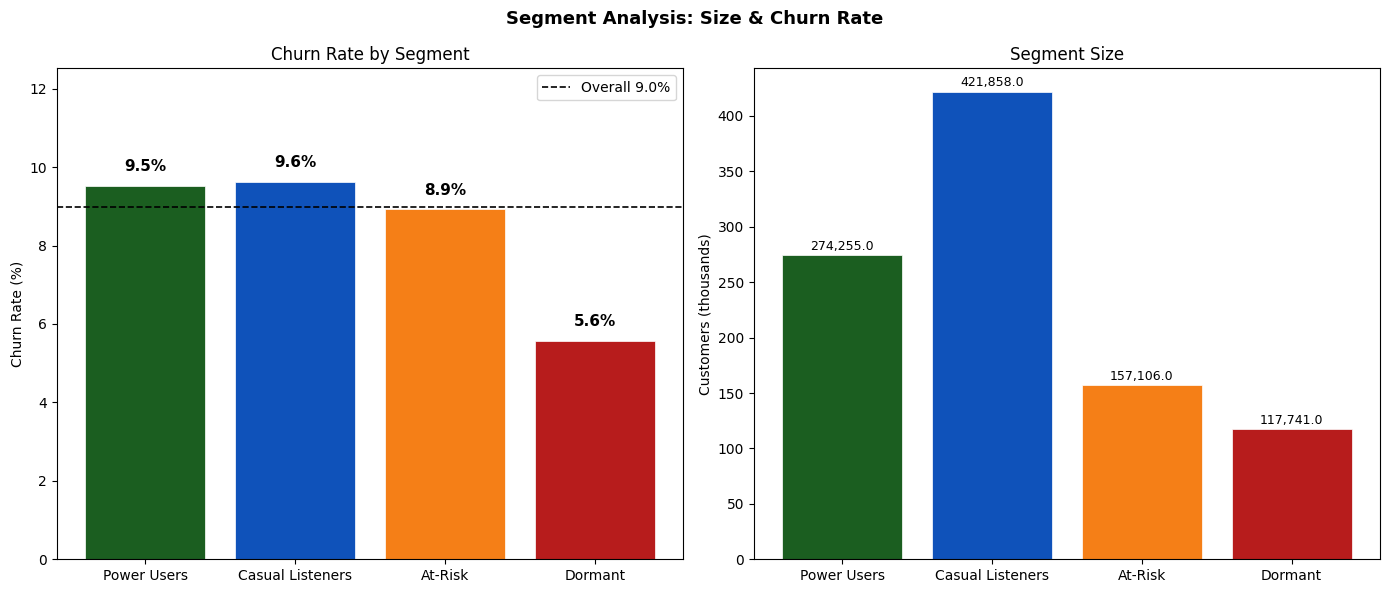

Saved: outputs/05_segment_churn.png

                  n_customers  churn_rate
segment_label                            
Power Users            274255        9.53
Casual Listeners       421858        9.63
At-Risk                157106        8.92
Dormant                117741        5.57


In [5]:
SEG_ORDER  = ["Power Users", "Casual Listeners", "At-Risk", "Dormant"]
SEG_COLORS = {
    "Power Users":      "#1B5E20",
    "Casual Listeners": "#0F52BA",
    "At-Risk":          "#F57F17",
    "Dormant":          "#B71C1C",
}

seg_summary = (
    df.groupby("segment_label")
    .agg(
        n_customers=("msno", "count"),
        churn_rate=("is_churn", "mean"),
    )
    .assign(churn_rate=lambda x: (x["churn_rate"] * 100).round(2))
    .reindex([s for s in SEG_ORDER if s in df["segment_label"].unique()])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Segment Analysis: Size & Churn Rate", fontsize=13, fontweight="bold")

# Bar: churn rate per segment
ax = axes[0]
bars = ax.bar(
    seg_summary.index,
    seg_summary["churn_rate"],
    color=[SEG_COLORS[s] for s in seg_summary.index],
    edgecolor="white", linewidth=0.5
)
ax.axhline(df["is_churn"].mean() * 100, color="black", linestyle="--",
           linewidth=1.2, label=f"Overall {df['is_churn'].mean()*100:.1f}%")
for bar, val in zip(bars, seg_summary["churn_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Segment")
ax.legend()
ax.set_ylim(0, seg_summary["churn_rate"].max() * 1.3)

# Bar: customer count per segment
ax = axes[1]
ax.bar(
    seg_summary.index,
    seg_summary["n_customers"] / 1000,
    color=[SEG_COLORS[s] for s in seg_summary.index],
    edgecolor="white", linewidth=0.5
)
for i, (seg, row) in enumerate(seg_summary.iterrows()):
    ax.text(i, row["n_customers"]/1000 + 2, f"{row['n_customers']:,}",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Customers (thousands)")
ax.set_title("Segment Size")

plt.tight_layout()
plt.savefig(OUTPUTS / "05_segment_churn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/05_segment_churn.png")
print()
print(seg_summary.to_string())

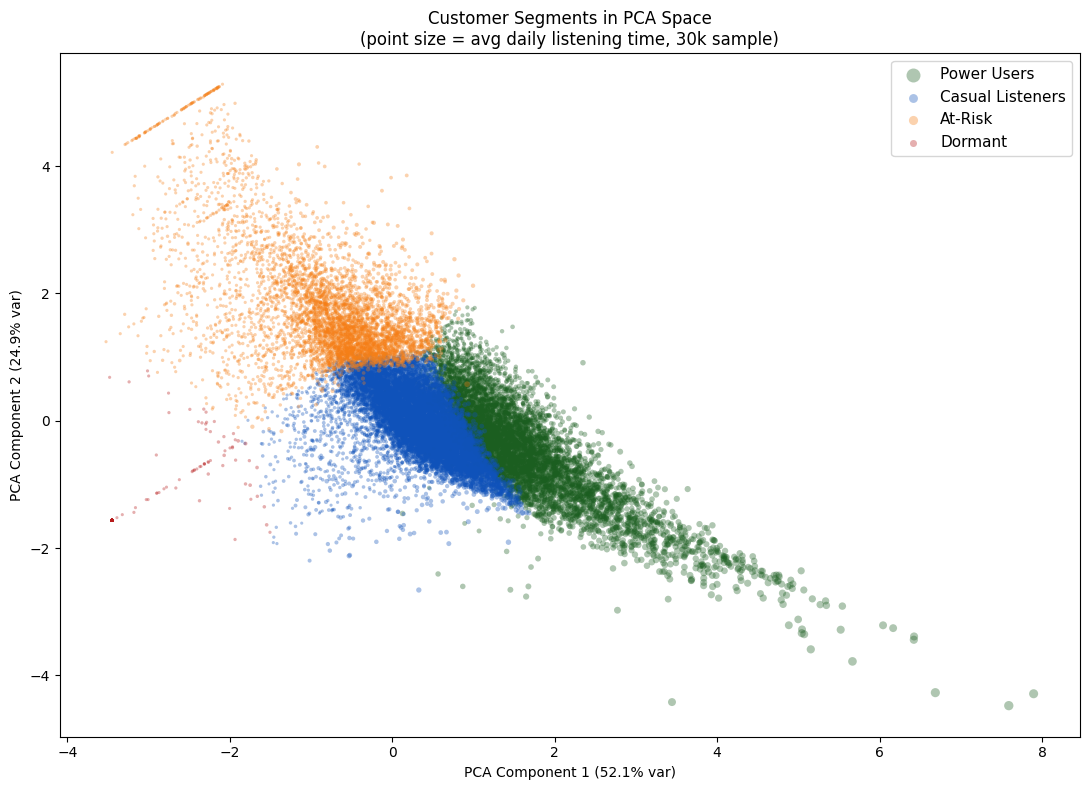

Saved: outputs/05_pca_scatter.png


In [6]:
# PCA 2D scatter — sample 30k for speed, size by avg_daily_secs
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

np.random.seed(42)
sample_idx = np.random.choice(len(df), 30_000, replace=False)
plot_df    = df.iloc[sample_idx].copy()

# Clip size values for scatter
size_raw = plot_df["avg_daily_secs"].clip(lower=0)
size_norm = ((size_raw - size_raw.min()) / (size_raw.max() - size_raw.min() + 1e-9) * 40 + 5)

fig, ax = plt.subplots(figsize=(11, 8))
for seg in SEG_ORDER:
    mask = plot_df["segment_label"] == seg
    ax.scatter(
        plot_df.loc[mask, "pca1"],
        plot_df.loc[mask, "pca2"],
        c=SEG_COLORS[seg], label=seg,
        s=size_norm[mask], alpha=0.35, linewidths=0
    )
ax.set_xlabel(f"PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Customer Segments in PCA Space\n(point size = avg daily listening time, 30k sample)")
ax.legend(markerscale=2, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS / "05_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/05_pca_scatter.png")

## Section 5 — Segment Profile Table & Save

In [7]:
seg_profiles = (
    df.groupby("segment_label")[CLUSTER_FEATURES + ["is_churn"]]
    .mean()
    .round(4)
    .assign(
        n_customers=df.groupby("segment_label").size(),
        churn_rate_pct=lambda x: (x["is_churn"] * 100).round(2)
    )
    .drop(columns=["is_churn"])
    .reindex([s for s in SEG_ORDER if s in df["segment_label"].unique()])
)

print("Segment profiles:")
print(seg_profiles.to_string())

# ── Save segment_profiles.csv ─────────────────────────────────────────────
profiles_path = OUTPUTS / "segment_profiles.csv"
seg_profiles.to_csv(profiles_path)
print(f"\nSaved: {profiles_path}")

# ── Add segment_label to kkbox_features.parquet ───────────────────────────
# Drop PCA columns (visualisation only) before saving
df_save = df.drop(columns=["cluster", "pca1", "pca2"])
features_path = OUTPUTS / "kkbox_features.parquet"
df_save.to_parquet(features_path, index=False)
print(f"Saved: {features_path}  (with segment_label column added)")
print(f"Shape: {df_save.shape[0]:,} rows x {df_save.shape[1]} cols")
print(f"Nulls: {df_save.isnull().sum().sum()}")

Segment profiles:
                  avg_daily_secs  completion_rate  skip_rate  active_days  days_since_last_log  n_customers  churn_rate_pct
segment_label                                                                                                              
Power Users           10529.6336           0.7711     0.1407     557.2108               3.3024       274255            9.53
Casual Listeners       5376.6698           0.7387     0.1571     179.3581              24.0292       421858            9.63
At-Risk                2918.6036           0.3742     0.4398     139.4935              66.8648       157106            8.92
Dormant                  18.2383           0.0041     0.0018       0.0822             815.4345       117741            5.57

Saved: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\outputs\segment_profiles.csv


Saved: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\outputs\kkbox_features.parquet  (with segment_label column added)
Shape: 970,960 rows x 40 cols
Nulls: 0
